# **1. Setup & Libraries**

In [ ]:
!pip install matplotlib-scalebar
!pip install contextily

# For post-hoc seasonal tests
!pip install scikit-posthocs

!pip install pymannkendall


In [ ]:
!pip install torch torch-geometric torch-scatter torch-sparse

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 12.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.3 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=676464 sha256=be9aec2623cfce2ba49603f7ca9119f026d003dca9cb1e91170f881c5aca3a02
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=1261337 sha256=e8129fba5eaaa1753e05ca82f9b152f11b5e440e35659c57ddcae9dc6311564a
  Stored in directory: /root/.cache/pip/wheels/71/fa/21/bd1d78ce1629aec4ecc924a63b82f6949dda484b6321eac6f2
Successfully built torch-scatte

In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")


CUDA available: False
Number of GPUs: 0
Using CPU


In [4]:
import os
import glob
import calendar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.ticker import ScalarFormatter
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns

from scipy.stats import mannwhitneyu, kruskal, wilcoxon
import pymannkendall as mk
import scikit_posthocs as sp


# **2. Load Dataset**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = "/content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/Data/Final processed 3-hourly rainfall data.csv"
df_rain = pd.read_csv(file_path)
df_rain

,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116614,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 09:00:00,2023,7,31,9,Monsoon,26.0,1016.0,1.0,10.0,73.0,0.0
2116615,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 12:00:00,2023,7,31,12,Monsoon,26.0,1016.0,0.0,0.0,82.0,0.0
2116616,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 15:00:00,2023,7,31,15,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0
2116617,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 18:00:00,2023,7,31,18,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0


In [7]:
# file_path = r"C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\Data\Final processed 3-hourly rainfall data with missing value.csv"
# df_rain = pd.read_csv(file_path)
# df_rain

In [8]:
# REMOVE THE LATE STATION (Example ID: 10325)
# Replace 10325 with the actual ID of the 2008 station
stations_to_drop = [11921]
df_rain = df_rain[~df_rain["StationID"].isin(stations_to_drop)].reset_index(drop=True)
df_rain


,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2069862,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 09:00:00,2023,7,31,9,Monsoon,26.0,1016.0,1.0,10.0,73.0,0.0
2069863,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 12:00:00,2023,7,31,12,Monsoon,26.0,1016.0,0.0,0.0,82.0,0.0
2069864,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 15:00:00,2023,7,31,15,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0
2069865,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 18:00:00,2023,7,31,18,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0


# **Hyperparameter Training**

In [ ]:
# ============================================================
# BASELINE: GraphOnly (GAT-only, uses ONLY last time step)
# + Hyperparameter Tuning (resume-safe, fixed-per-trial hp)
#
# Output heads:
#   - Probabilistic rainfall (quantiles) for H_out steps (log1p space)
#   - 3 risk heads: flash / peak24 / acc24
#
# Composite objective (lower is better):
#   composite = 0.5*norm(CRPS_log) + 0.5*norm(mean_brier)
# ============================================================

import os, json, math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 0.5) Mount Google Drive (Colab)
# ============================================================
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Colab drive not mounted (not in Colab or mount failed).")

SAVE_DIR = "/content/drive/MyDrive/Rainfall/Baselines/GraphOnly/Tuning_v1"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving to:", SAVE_DIR)

# ============================================================
# 1) Utilities (incl. graph building)
# ============================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values  # assumed 0..N-1
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]  # skip self
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T   # [2, E]
    return edge_index_np


class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()
        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)
        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled = scaler.transform(X_flat).reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc  = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 2) Preprocessing (FULL GRID)
# ============================================================
def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR -> sin/cos
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y    = M_in[..., rain_idx]

    # time features: hour + month cyclical
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # season by time
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
    }

# ============================================================
# 3) Dataset (same as ENS style)
# ============================================================
class BanglaRainDataset(Dataset):
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x  = self.X_scaled[t-self.T_in+1:t+1]
        m  = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y  = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash at t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash  = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24 over window
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24 from precomputed Acc24
        acc  = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash), torch.from_numpy(mflash),
            torch.from_numpy(peak24), torch.from_numpy(mpeak),
            torch.from_numpy(acc24),  torch.from_numpy(macc),
        )

# ============================================================
# 4) Model: GraphOnly GAT (uses last input time only)
# ============================================================
class GraphOnlyGAT(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1,0.5,0.9),
        d_model=96,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        self.q_head = nn.Linear(d_model, H_out * self.K)
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        # x: [B,T_in,N,F] -> use last step only
        B, T, N, Fin = x.shape
        assert N == self.N

        x_last = x[:, -1, :, :]              # [B,N,F]
        h_last = self.input_proj(x_last)     # [B,N,d]

        reg = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg              # [B,N,d]

        # batch edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)            # [B*N,d]
        ei = edge_index.to(x_nodes.device)                      # [2,E] on same device
        edge_batch = torch.cat([ei + b*N for b in range(B)], dim=1)  # [2,B*E]

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        q = self.q_head(g).view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()
        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)
        return q, flash_logits, peak_logits, acc_logits

# ============================================================
# 5) Train/Eval
# ============================================================
def compute_pos_weight(labels, masks):
    with torch.no_grad():
        pos = (labels * masks).sum().item()
        tot = masks.sum().item()
        neg = tot - pos
        if pos < 1:
            return 1.0
        w = (neg + 1e-6) / (pos + 1e-6)
        return float(np.clip(w, 1.0, 30.0))


def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)


def train_one_epoch(model, loader, edge_index, optimizer, quantiles, weights):
    model.train()
    total = 0.0
    nb = 0
    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        optimizer.zero_grad()
        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        # quantile loss
        q_losses = [pinball_loss(q_hat[..., k], y_log, qv, mask=my) for k, qv in enumerate(quantiles)]
        loss_q = torch.stack(q_losses).mean()

        # risk losses
        loss_flash = masked_bce_with_logits(flash_logits, flash, mflash, weights["pos_w_flash"])
        loss_peak  = masked_bce_with_logits(peak_logits,  peak,  mpeak,  weights["pos_w_peak"])
        loss_acc   = masked_bce_with_logits(acc_logits,   acc,   macc,   weights["pos_w_acc"])

        # crossing penalty
        q10 = q_hat[..., 0]
        q50 = q_hat[..., 1] if q_hat.size(-1) > 1 else q10
        q90 = q_hat[..., 2] if q_hat.size(-1) > 2 else q50
        phys_pen = (F.relu(q10 - q50) + F.relu(q50 - q90))
        phys_pen = (phys_pen * my).sum() / my.sum().clamp_min(1.0)

        loss = (
            weights["lambda_q"]     * loss_q +
            weights["lambda_flash"] * loss_flash +
            weights["lambda_peak"]  * loss_peak +
            weights["lambda_acc"]   * loss_acc +
            weights["lambda_phys"]  * phys_pen
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
        nb += 1
    return total / max(nb, 1)


@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm  += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))
    out.update({"MAE_mm_by_lead": maes, "RMSE_mm_by_lead": rmses, "n_valid_by_lead": counts})

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)
    return out

# ============================================================
# 6) Build data objects (incl. edge_index)
# ============================================================
def build_data_objects(df_rain, k_nn=4, T_in=16, H_out=8, train_frac=0.7, val_frac=0.15):
    prep = prepare_full_grid(df_rain)
    stations = prep["stations"]
    N = len(stations)

    edge_index_np = build_knn_graph(stations, k=k_nn)
    edge_index = torch.tensor(edge_index_np, dtype=torch.long)  # keep on CPU

    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=train_frac, val_frac=val_frac)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)

    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=H_out)
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=T_in, H_out=H_out
    )
    ds_val = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=T_in, H_out=H_out
    )
    ds_test = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=val_end, t_end=T,
        T_in=T_in, H_out=H_out
    )

    return prep, edge_index, scaler, (thr3h, thrAcc24), (ds_train, ds_val, ds_test)


def make_loaders(ds_train, ds_val, ds_test, batch_size=32):
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def infer_input_dim(train_loader):
    x0, *_ = next(iter(train_loader))
    return x0.shape[-1]

# ============================================================
# 7) Single run (final training)
# ============================================================
def run_graph_only(
    df_rain,
    k_nn=4,
    T_in=16,
    H_out=8,
    quantiles=(0.1,0.5,0.9),
    train_frac=0.7,
    val_frac=0.15,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=10,
    d_model=96,
    num_gat_layers=2,
    gat_heads=2,
    dropout=0.1,
    lambda_q=1.0,
    lambda_flash=2.0,
    lambda_peak=2.0,
    lambda_acc=2.0,
    lambda_phys=0.2,
    seed=42
):
    set_seed(seed, deterministic=False)

    prep, edge_index, scaler, (thr3h, thrAcc24), (ds_train, ds_val, ds_test) = build_data_objects(
        df_rain, k_nn=k_nn, T_in=T_in, H_out=H_out, train_frac=train_frac, val_frac=val_frac
    )
    train_loader, val_loader, test_loader = make_loaders(ds_train, ds_val, ds_test, batch_size=batch_size)

    F_in = infer_input_dim(train_loader)
    N = len(prep["stations"])

    # pos weights from train
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    model = GraphOnlyGAT(
        num_stations=N,
        in_features=F_in,
        T_in=T_in,
        H_out=H_out,
        num_seasons=len(prep["unique_seasons"]),
        quantiles=quantiles,
        d_model=d_model,
        num_gat_layers=num_gat_layers,
        gat_heads=gat_heads,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    weights = {
        "lambda_q": lambda_q,
        "lambda_flash": lambda_flash,
        "lambda_peak":  lambda_peak,
        "lambda_acc":   lambda_acc,
        "lambda_phys":  lambda_phys,
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        tr_loss = train_one_epoch(model, train_loader, edge_index, optimizer, quantiles, weights)
        val_scores = evaluate(model, val_loader, edge_index, quantiles)
        val_key = float(val_scores["CRPS_log"])

        if val_key < best_val:
            best_val = val_key
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {ep:02d} | train={tr_loss:.4f} | val_CRPS_log={val_scores['CRPS_log']:.4f} | "
              f"val_BS_flash={val_scores['Brier_flash']:.4f} | val_BS_peak={val_scores['Brier_peak']:.4f} | "
              f"val_BS_acc={val_scores['Brier_acc']:.4f} {'BEST' if val_key==best_val else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)

    test_scores = evaluate(model, test_loader, edge_index, quantiles)
    return model, prep, scaler, (thr3h, thrAcc24), test_scores

# ============================================================
# 8) Hyperparameter tuning (resume-safe)
# ============================================================
def build_model_and_optimizer_from_hp(hp, N, F_in, num_seasons):
    model = GraphOnlyGAT(
        num_stations=N,
        in_features=F_in,
        T_in=hp["T_in"],
        H_out=hp["H_out"],
        num_seasons=num_seasons,
        quantiles=hp["quantiles"],
        d_model=hp["d_model"],
        num_gat_layers=hp["num_gat_layers"],
        gat_heads=hp["gat_heads"],
        dropout=hp["dropout"],
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
    return model, optimizer


def sample_hparams(rng):
    H_out = 8
    hp = {
        "k_nn": int(rng.choice([3,4,5,6,7])),
        "T_in": int(rng.choice([16, 24, 32])),
        "H_out": H_out,

        "d_model": int(rng.choice([64, 96, 128])),
        "num_gat_layers": int(rng.choice([1,2,3])),
        "gat_heads": int(rng.choice([1,2,4])),
        "dropout": float(rng.choice([0.1,0.2,0.3])),

        "lr": float(rng.choice([5e-4, 1e-3, 2e-3])),
        "weight_decay": float(rng.choice([1e-5, 1e-4])),

        "lambda_q": 1.0,
        "lambda_flash": 2.0,
        "lambda_peak": 2.0,
        "lambda_acc": 2.0,
        "lambda_phys": float(rng.choice([0.0, 0.1, 0.25])),

        "batch_size": int(rng.choice([8,16,32])),
        "epochs": 10,
        "quantiles": (0.1,0.5,0.9),
    }

    # safety for large configs
    if hp["T_in"] == 32 and hp["d_model"] == 128 and hp["num_gat_layers"] >= 3:
        hp["batch_size"] = int(min(hp["batch_size"], 16))
    return hp


def run_one_trial(df_rain, trial_id, hp, trial_dir, base_seed=42):
    set_seed(base_seed + trial_id, deterministic=False)

    prep, edge_index, scaler, thresholds, (ds_train, ds_val, _) = build_data_objects(
        df_rain, k_nn=hp["k_nn"], T_in=hp["T_in"], H_out=hp["H_out"], train_frac=0.7, val_frac=0.15
    )

    train_loader = DataLoader(ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val,   batch_size=hp["batch_size"], shuffle=False)

    F_in = infer_input_dim(train_loader)
    N = len(prep["stations"])
    num_seasons = len(prep["unique_seasons"])

    # pos weights
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    model, optimizer = build_model_and_optimizer_from_hp(hp, N=N, F_in=F_in, num_seasons=num_seasons)

    weights = {
        "lambda_q": hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "lambda_phys":  hp["lambda_phys"],
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_val = float("inf")
    best_state = None
    best_epoch = -1
    best_metrics = None
    trial_log = []

    for ep in range(1, hp["epochs"] + 1):
        tr_loss = train_one_epoch(model, train_loader, edge_index, optimizer, hp["quantiles"], weights)
        val_scores = evaluate(model, val_loader, edge_index, hp["quantiles"])

        val_key = float(val_scores["CRPS_log"])
        trial_log.append({
            "trial": trial_id,
            "epoch": ep,
            "train_loss": float(tr_loss),
            "val_CRPS_log": val_key,
            "val_CRPS_mm": float(val_scores["CRPS_mm"]),
            "val_Brier_flash": float(val_scores["Brier_flash"]),
            "val_Brier_peak": float(val_scores["Brier_peak"]),
            "val_Brier_acc": float(val_scores["Brier_acc"]),
        })

        print(f"[Trial {trial_id:02d}] Epoch {ep:02d} | train={tr_loss:.4f} | val_CRPS_log={val_key:.4f}")

        if val_key < best_val:
            best_val = val_key
            best_epoch = ep
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    ckpt_path = os.path.join(trial_dir, "best_model.pt")
    torch.save({
        "best_val_CRPS_log": best_val,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,
        "hparams": hp,
        "state_dict": best_state,
        "scaler_mean": getattr(scaler, "mean_", None),
        "scaler_std": getattr(scaler, "std_", None),
    }, ckpt_path)

    pd.DataFrame(trial_log).to_csv(os.path.join(trial_dir, "epoch_log.csv"), index=False)

    return {
        "trial": int(trial_id),
        "best_val_CRPS_log": float(best_val),
        "best_epoch": int(best_epoch),
        "ckpt_path": ckpt_path,
        "val_Brier_flash": float(best_metrics["Brier_flash"]) if best_metrics is not None else np.nan,
        "val_Brier_peak":  float(best_metrics["Brier_peak"])  if best_metrics is not None else np.nan,
        "val_Brier_acc":   float(best_metrics["Brier_acc"])   if best_metrics is not None else np.nan,
        **hp
    }


def tune_graph_only(df_rain, n_trials=10, base_seed=42):
    rng = np.random.RandomState(base_seed)
    summary_path = os.path.join(SAVE_DIR, "tuning_summary.csv")
    all_results = []

    if os.path.exists(summary_path):
        try:
            existing = pd.read_csv(summary_path)
            if len(existing) > 0 and "trial" in existing.columns:
                all_results = existing.to_dict("records")
                print(f"✅ Resume: found {len(existing)} rows in tuning_summary.csv")
        except Exception as e:
            print("⚠️ Could not load existing summary, starting fresh:", str(e))

    for t in range(n_trials):
        trial_dir = os.path.join(SAVE_DIR, f"trial_{t:02d}")
        os.makedirs(trial_dir, exist_ok=True)

        hp_path = os.path.join(trial_dir, "hparams.json")
        ckpt_path = os.path.join(trial_dir, "best_model.pt")

        if os.path.exists(ckpt_path):
            print(f"[Trial {t:02d}] ✅ best_model.pt exists -> skipping.")
            continue

        if os.path.exists(hp_path):
            with open(hp_path, "r") as f:
                hp = json.load(f)
            print(f"\n[Trial {t:02d}] ✅ Reusing saved hyperparameters: {hp_path}")
        else:
            hp = sample_hparams(rng)
            with open(hp_path, "w") as f:
                json.dump(hp, f, indent=2)
            print(f"\n[Trial {t:02d}] 💾 Sampled+saved hyperparameters: {hp_path}")

        print("\n" + "="*80)
        print(f"Starting Trial {t:02d} with hparams:\n{hp}")
        print("="*80)

        try:
            res = run_one_trial(df_rain, trial_id=t, hp=hp, trial_dir=trial_dir, base_seed=base_seed)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"[Trial {t:02d}] CUDA OOM -> skipping (hp kept).")
                torch.cuda.empty_cache()
                continue
            raise e

        all_results.append(res)
        pd.DataFrame(all_results).to_csv(summary_path, index=False)

    results_df = pd.read_csv(summary_path) if os.path.exists(summary_path) else pd.DataFrame(all_results)
    if len(results_df) == 0:
        raise RuntimeError("No successful trials completed.")

    eps = 1e-12
    results_df["mean_brier"] = (
        results_df["val_Brier_flash"].astype(float) +
        results_df["val_Brier_peak"].astype(float) +
        results_df["val_Brier_acc"].astype(float)
    ) / 3.0

    crps = results_df["best_val_CRPS_log"].astype(float)
    bri  = results_df["mean_brier"].astype(float)
    crps_n = (crps - crps.min()) / (crps.max() - crps.min() + eps)
    bri_n  = (bri  - bri.min())  / (bri.max()  - bri.min()  + eps)

    results_df["composite_obj"] = 0.5*crps_n + 0.5*bri_n
    results_df = results_df.sort_values("composite_obj", ascending=True)
    results_df.to_csv(summary_path, index=False)

    best = results_df.iloc[0].to_dict()
    with open(os.path.join(SAVE_DIR, "best_trial.json"), "w") as f:
        json.dump(best, f, indent=2)

    print("\n✅ Tuning finished.")
    print("Best trial:", int(best["trial"]))
    print("Best composite objective:", best["composite_obj"])
    print("Best val CRPS_log:", best["best_val_CRPS_log"])
    print("Best mean Brier:", best["mean_brier"])
    print("Checkpoint:", best["ckpt_path"])
    return results_df, best

# ============================================================
# 9) RUN
# ============================================================
# 1) Hyperparameter tuning:
# df_rain = pd.read_csv(".../df_rain.csv")
results_df, best_trial = tune_graph_only(df_rain, n_trials=15, base_seed=42)


Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving to: /content/drive/MyDrive/Rainfall/Baselines/GraphOnly/Tuning_v1

[Trial 00] 💾 Sampled+saved hyperparameters: /content/drive/MyDrive/Rainfall/Baselines/GraphOnly/Tuning_v1/trial_00/hparams.json

Starting Trial 00 with hparams:
{'k_nn': 6, 'T_in': 16, 'H_out': 8, 'd_model': 128, 'num_gat_layers': 3, 'gat_heads': 1, 'dropout': 0.1, 'lr': 0.002, 'weight_decay': 0.0001, 'lambda_q': 1.0, 'lambda_flash': 2.0, 'lambda_peak': 2.0, 'lambda_acc': 2.0, 'lambda_phys': 0.25, 'batch_size': 32, 'epochs': 10, 'quantiles': (0.1, 0.5, 0.9)}
Total stations: 34
Total unique times: 61360


/tmp/ipython-input-2681876238.py:367: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 00] Epoch 01 | train=4.7790 | val_CRPS_log=0.1504


/tmp/ipython-input-2681876238.py:367: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 00] Epoch 02 | train=4.6059 | val_CRPS_log=0.1475


...

[Trial 14] Epoch 08 | train=4.4463 | val_CRPS_log=0.1378


/tmp/ipython-input-2681876238.py:367: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 14] Epoch 09 | train=4.4360 | val_CRPS_log=0.1375


/tmp/ipython-input-2681876238.py:367: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 14] Epoch 10 | train=4.4253 | val_CRPS_log=0.1378

✅ Tuning finished.
Best trial: 13
Best composite objective: 0.1426113060310552
Best val CRPS_log: 0.1399824311737724
Best mean Brier: 0.1416108461610042
Checkpoint: /content/drive/MyDrive/Rainfall/Baselines/GraphOnly/Tuning_v1/trial_13/best_model.pt


# **Model Training**

In [ ]:
# ============================================================
# GraphOnly GAT: Final Training Script (Standalone)
# ------------------------------------------------------------
# - Assumes df_rain is already loaded in memory (DataFrame)
# - Assumes best_trial.json exists (from previous tuning) at:
#     TUNING_SAVE_DIR/best_trial.json
# - Loads best hyperparameters
# - Trains final GraphOnly GAT model with:
#     * early stopping on val CRPS_log
#     * per-epoch metrics printed + logged
# - Saves to Google Drive:
#     * final_epoch_log.csv
#     * final_best_model.pt
# ============================================================

import os
import json
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# (Optional) Colab mount
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Colab drive not mounted (not in Colab or mount failed).")

# Path where tuning saved best_trial.json
TUNING_SAVE_DIR = r"C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\Baselines\GraphOnly\Tuning_v1"
os.makedirs(TUNING_SAVE_DIR, exist_ok=True)
print("Tuning directory:", TUNING_SAVE_DIR)

# Path where final model + logs will be saved
FINAL_SAVE_DIR = r"C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\Baselines\GraphOnly\Final_Run\v2"
os.makedirs(FINAL_SAVE_DIR, exist_ok=True)
print("Final run artifacts will be saved to:", FINAL_SAVE_DIR)

# ============================================================
# 1) Utilities (same as tuning)
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values  # assumed 0..N-1
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]  # skip self
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T   # [2, E]
    return edge_index_np


class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()
        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)
        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }

# ============================================================
# 2) Preprocessing (FULL GRID) – same as tuning
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR -> sin/cos
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y    = M_in[..., rain_idx]

    # time features: hour + month cyclical
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin  = np.sin(2*np.pi*(hour/24.0))
    hour_cos  = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # season by time
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
    }

# ============================================================
# 3) Split, scaling, targets (same as tuning)
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled = scaler.transform(X_flat).reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc  = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 4) Dataset (same as tuning)
# ============================================================

class BanglaRainDataset(Dataset):
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x  = self.X_scaled[t-self.T_in+1:t+1]
        m  = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y  = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash at t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash  = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24 over window
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc  = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash), torch.from_numpy(mflash),
            torch.from_numpy(peak24), torch.from_numpy(mpeak),
            torch.from_numpy(acc24),  torch.from_numpy(macc),
        )

# ============================================================
# 5) Model: GraphOnly GAT (same as tuning)
# ============================================================

class GraphOnlyGAT(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95),
        d_model=96,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        self.q_head = nn.Linear(d_model, H_out * self.K)
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        # x: [B,T_in,N,F] -> use last step only
        B, T, N, Fin = x.shape
        assert N == self.N

        x_last = x[:, -1, :, :]              # [B,N,F]
        h_last = self.input_proj(x_last)     # [B,N,d]

        reg = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg              # [B,N,d]

        # batch edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)            # [B*N,d]
        ei = edge_index.to(x_nodes.device)                      # [2,E]
        edge_batch = torch.cat([ei + b*N for b in range(B)], dim=1)  # [2,B*E]

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        q = self.q_head(g).view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()
        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)
        return q, flash_logits, peak_logits, acc_logits

# ============================================================
# 6) Train / Eval (same as tuning)
# ============================================================

def compute_pos_weight(labels, masks):
    with torch.no_grad():
        pos = (labels * masks).sum().item()
        tot = masks.sum().item()
        neg = tot - pos
        if pos < 1:
            return 1.0
        w = (neg + 1e-6) / (pos + 1e-6)
        return float(np.clip(w, 1.0, 30.0))


def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)


def train_one_epoch(model, loader, edge_index, optimizer, quantiles, weights):
    model.train()
    total = 0.0
    nb = 0
    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        optimizer.zero_grad()
        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        # quantile loss
        q_losses = [pinball_loss(q_hat[..., k], y_log, qv, mask=my) for k, qv in enumerate(quantiles)]
        loss_q = torch.stack(q_losses).mean()

        # risk losses
        loss_flash = masked_bce_with_logits(flash_logits, flash, mflash, weights["pos_w_flash"])
        loss_peak  = masked_bce_with_logits(peak_logits,  peak,  mpeak,  weights["pos_w_peak"])
        loss_acc   = masked_bce_with_logits(acc_logits,   acc,   macc,   weights["pos_w_acc"])

        # Replace the hardcoded quantile crossing penalty with:
        phys_pen = 0.0
        for k in range(q_hat.size(-1) - 1):
            phys_pen += F.relu(q_hat[..., k] - q_hat[..., k+1])
        phys_pen = (phys_pen * my).sum() / my.sum().clamp_min(1.0)

        loss = (
            weights["lambda_q"]     * loss_q +
            weights["lambda_flash"] * loss_flash +
            weights["lambda_peak"]  * loss_peak +
            weights["lambda_acc"]   * loss_acc +
            weights["lambda_phys"]  * phys_pen
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
        nb += 1
    return total / max(nb, 1)


@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm  += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))
    out.update({"MAE_mm_by_lead": maes, "RMSE_mm_by_lead": rmses, "n_valid_by_lead": counts})

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)
    return out

# ============================================================
# 7) Hparams loader from best_trial.json (GraphOnly)
# ============================================================

def load_best_hparams(best_trial_path):
    with open(best_trial_path, "r") as f:
        best = json.load(f)

    hp = {
        "k_nn": 5,
        "T_in": 16,
        "H_out": 8,
        "d_model": 64,
        "num_gat_layers": 2,
        "gat_heads": 4,
        "dropout": 0.3,
        "lr": 0.001,
        "weight_decay": 0.00001,
        "lambda_q": 1,
        "lambda_flash": 2,
        "lambda_peak": 2,
        "lambda_acc": 2,
        "lambda_phys": 0.25,
        "batch_size": 8,
        "quantiles": (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95),
    }
    return hp

# ============================================================
# 8) Final training with early stopping
# ============================================================

def final_train_graphonly(df_rain,
                          hp,
                          final_save_dir=FINAL_SAVE_DIR,
                          train_frac=0.7,
                          val_frac=0.15,
                          base_seed=42,
                          max_epochs=None,
                          patience=5):
    """
    Final training run with fixed hyperparameters (hp) for GraphOnly GAT.
    - Early stopping on val CRPS_log
    - Saves:
        * final_best_model.pt
        * final_epoch_log.csv
    """
    if max_epochs is None:
        max_epochs = hp["epochs"]

    set_seed(base_seed, deterministic=False)

    prep = prepare_full_grid(df_rain)
    stations = prep["stations"]
    N = len(stations)

    edge_index_np = build_knn_graph(stations, k=hp["k_nn"])
    edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=train_frac, val_frac=val_frac)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=hp["H_out"])
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=hp["T_in"], H_out=hp["H_out"]
    )
    ds_val = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=hp["T_in"], H_out=hp["H_out"]
    )

    train_loader = DataLoader(ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val,   batch_size=hp["batch_size"], shuffle=False)

    x0, *_ = next(iter(train_loader))
    F_in = x0.shape[-1]

    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    model = GraphOnlyGAT(
        num_stations=N,
        in_features=F_in,
        T_in=hp["T_in"],
        H_out=hp["H_out"],
        num_seasons=len(prep["unique_seasons"]),
        quantiles=hp["quantiles"],
        d_model=hp["d_model"],
        num_gat_layers=hp["num_gat_layers"],
        gat_heads=hp["gat_heads"],
        dropout=hp["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"],
    )

    weights = {
        "lambda_q": hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "lambda_phys":  hp["lambda_phys"],
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_val = float("inf")
    best_state = None
    best_epoch = -1
    best_metrics = None
    epoch_log = []
    epochs_since_improve = 0

    for ep in range(1, max_epochs + 1):
        tr_loss = train_one_epoch(
            model, train_loader, edge_index, optimizer,
            quantiles=hp["quantiles"], weights=weights
        )
        val_scores = evaluate(
            model, val_loader, edge_index,
            quantiles=hp["quantiles"]
        )

        val_key = float(val_scores["CRPS_log"])

        row = {
            "epoch": ep,
            "train_loss": float(tr_loss),
            "val_CRPS_log": val_key,
            "val_CRPS_mm": float(val_scores["CRPS_mm"]),
            "val_Brier_flash": float(val_scores["Brier_flash"]),
            "val_Brier_peak": float(val_scores["Brier_peak"]),
            "val_Brier_acc": float(val_scores["Brier_acc"]),
        }
        epoch_log.append(row)

        print(
            f"[FINAL GraphOnly] Epoch {ep:02d} | "
            f"train={tr_loss:.4f} | "
            f"val_CRPS_log={val_key:.4f} | "
            f"val_CRPS_mm={val_scores['CRPS_mm']:.4f} | "
            f"val_BS_flash={val_scores['Brier_flash']:.4f} | "
            f"val_BS_peak={val_scores['Brier_peak']:.4f} | "
            f"val_BS_acc={val_scores['Brier_acc']:.4f}"
        )

        if val_key < best_val - 1e-6:
            best_val = val_key
            best_epoch = ep
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_since_improve = 0
            print(f"   -> New best epoch {ep:02d} (val_CRPS_log={best_val:.4f})")
        else:
            epochs_since_improve += 1
            print(f"   -> No improvement for {epochs_since_improve} epoch(s)")

        log_path = os.path.join(final_save_dir, "final_epoch_log.csv")
        pd.DataFrame(epoch_log).to_csv(log_path, index=False)

        if epochs_since_improve >= patience:
            print(f"\n[EARLY STOP] No improvement in {patience} epochs. Stopping at epoch {ep}.")
            break

    ckpt_path = os.path.join(final_save_dir, "final_best_model.pt")
    torch.save({
        "best_val_CRPS_log": best_val,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,
        "hparams": hp,
        "state_dict": best_state,
        "scaler_mean": getattr(scaler, "mean_", None),
        "scaler_std": getattr(scaler, "std_", None),
        "thr3h": thr3h,
        "thrAcc24": thrAcc24,
        "stations": prep["stations"],
        "times": prep["times"],
        "train_frac": float(train_frac),
        "val_frac": float(val_frac),
    }, ckpt_path)

    print("\n[FINAL GraphOnly] Training finished.")
    print("Best epoch:", best_epoch, "| best val CRPS_log:", best_val)
    print("Checkpoint saved to:", ckpt_path)
    print("Epoch log saved to:", log_path)

    return {
        "best_epoch": best_epoch,
        "best_val_CRPS_log": best_val,
        "ckpt_path": ckpt_path,
        "log_path": log_path,
        "hp": hp,
    }

# ============================================================
# 9) Run final training (example)
# ============================================================

# df_rain must be in memory:
# df_rain = pd.read_csv("path/to/df_rain.csv")

best_trial_path = os.path.join(TUNING_SAVE_DIR, "best_trial.json")
best_hp = load_best_hparams(best_trial_path)

# Optional override of epochs:
best_hp["epochs"] = 50  # e.g. final run up to 20 epochs

final_results = final_train_graphonly(
    df_rain=df_rain,
    hp=best_hp,
    final_save_dir=FINAL_SAVE_DIR,
    train_frac=0.7,
    val_frac=0.15,
    base_seed=42,
    max_epochs=best_hp["epochs"],
    patience=10,
)

print("\nFinal GraphOnly results summary:")
print(final_results)


Using device: cuda
Colab drive not mounted (not in Colab or mount failed).
Tuning directory: C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\Baselines\GraphOnly\Tuning_v1
Final run artifacts will be saved to: C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\Baselines\GraphOnly\Final_Run\v2
Total stations: 34
Total unique times: 61360


C:\Users\deepn\AppData\Local\Temp\ipykernel_6868\650221733.py:383: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL GraphOnly] Epoch 01 | train=4.7481 | val_CRPS_log=0.1382 | val_CRPS_mm=4192.0047 | val_BS_flash=0.1448 | val_BS_peak=0.1627 | val_BS_acc=0.1661
   -> New best epoch 01 (val_CRPS_log=0.1382)


C:\Users\deepn\AppData\Local\Temp\ipykernel_6868\650221733.py:383: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL GraphOnly] Epoch 02 | train=4.5787 | val_CRPS_log=0.1336 | val_CRPS_mm=96349979.7800 | val_BS_flash=0.1241 | val_BS_peak=0.1582 | val_BS_acc=0.1529
   -> New best epoch 02 (val_CRPS_log=0.1336)


...

[FINAL GraphOnly] Epoch 36 | train=4.3352 | val_CRPS_log=0.1350 | val_CRPS_mm=inf | val_BS_flash=0.1238 | val_BS_peak=0.1562 | val_BS_acc=0.1393
   -> No improvement for 8 epoch(s)


C:\Users\deepn\AppData\Local\Temp\ipykernel_6868\650221733.py:383: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL GraphOnly] Epoch 37 | train=4.3383 | val_CRPS_log=0.1345 | val_CRPS_mm=inf | val_BS_flash=0.1194 | val_BS_peak=0.1525 | val_BS_acc=0.1291
   -> No improvement for 9 epoch(s)


C:\Users\deepn\AppData\Local\Temp\ipykernel_6868\650221733.py:383: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL GraphOnly] Epoch 38 | train=4.3333 | val_CRPS_log=0.1354 | val_CRPS_mm=inf | val_BS_flash=0.1221 | val_BS_peak=0.1519 | val_BS_acc=0.1384
   -> No improvement for 10 epoch(s)

[EARLY STOP] No improvement in 10 epochs. Stopping at epoch 38.

[FINAL GraphOnly] Training finished.
Best epoch: 28 | best val CRPS_log: 0.13268419424617883
Checkpoint saved to: C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\Baselines\GraphOnly\Final_Run\v2\final_best_model.pt
Epoch log saved to: C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\Baselines\GraphOnly\Final_Run\v2\final_epoch_log.csv

Final GraphOnly results summary:
{'best_epoch': 28, 'best_val_CRPS_log': 0.13268419424617883, 'ckpt_path': 'C:\\Users\\deepn\\Documents\\Rainfall_Training_Research_Lab\\Baselines\\GraphOnly\\Final_Run\\v2\\final_best_model.pt', 'log_path': 'C:\\Users\\deepn\\Documents\\Rainfall_Training_Research_Lab\\Baselines\\GraphOnly\\Final_Run\\v2\\final_epoch_log.csv', 'hp': {'k_nn': 5, 'T_in': 16, 'H_out':

# Testing

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Checkpoint path: /content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/GraphOnly/Final_Run/v2/final_best_model.pt
Log path       : /content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/GraphOnly/Final_Run/v2/final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1327
  best_epoch       : 28
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Test dataset size: 9181
Input feature dim: 18

Model rebuilt and weights loaded.


/tmp/ipykernel_4780/1830897525.py:344: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)



========== GRAPHONLY TEST METRICS ==========
CRPS_log   : 0.1123
CRPS_mm    : 0.6144
Brier_flash: 0.1032
Brier_peak : 0.1438
Brier_acc  : 0.1232

[Flash 3h]  PR-AUC=0.3870, ROC-AUC=0.9155, n_valid=307503
[Peak24]   PR-AUC=0.5973, ROC-AUC=0.8737, n_valid=307535
[Acc24]    PR-AUC=0.2476, ROC-AUC=0.8717, n_valid=307195

Loaded epoch log with 38 rows.


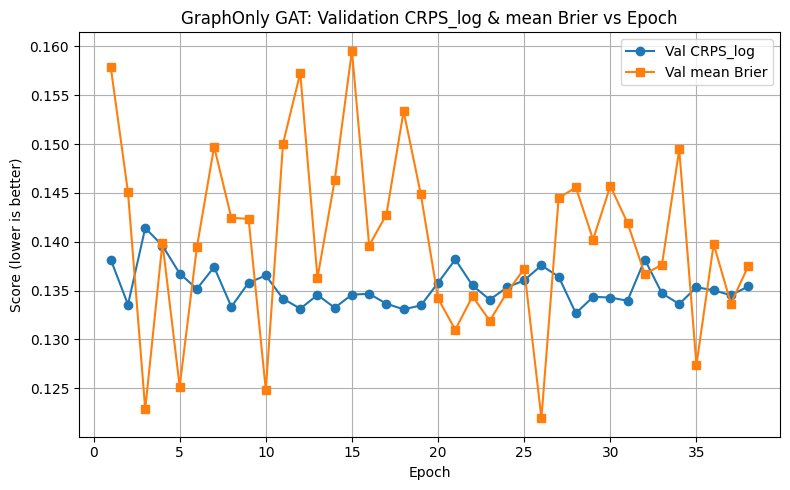

In [9]:
# ============================================================
# GraphOnly GAT — Standalone TESTING Script
# ------------------------------------------------------------
# - Assumes df_rain is already loaded in memory (DataFrame)
# - Assumes final_best_model.pt exists at:
#     FINAL_SAVE_DIR/final_best_model.pt
# - Reloads best hyperparameters + weights
# - Rebuilds preprocessing and TEST set
# - Evaluates on TEST split (no retraining)
# - Optionally plots validation metrics vs epoch
# ============================================================

import os
import json
import math
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

import matplotlib.pyplot as plt

# (Optional) Colab mount
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Colab drive not mounted (not in Colab or mount failed).")

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 1) Utilities (same as training/tuning)
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values  # assumed 0..N-1
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]  # skip self
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T   # [2, E]
    return edge_index_np


class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        std_safe = np.where(self.std_ < self.eps, 1.0, self.std_)
        return (X - self.mean_) / std_safe


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()
        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)
        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end


def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc  = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 2) Preprocessing (FULL GRID) – same as training
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR -> sin/cos
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y    = M_in[..., rain_idx]

    # time features: hour + month cyclical
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin  = np.sin(2*np.pi*(hour/24.0))
    hour_cos  = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # season by time
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
    }

# ============================================================
# 3) Dataset (same as training)
# ============================================================

class BanglaRainDataset(Dataset):
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x  = self.X_scaled[t-self.T_in+1:t+1]
        m  = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y  = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash at t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash  = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24 over window
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24 from precomputed Acc24
        acc  = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash), torch.from_numpy(mflash),
            torch.from_numpy(peak24), torch.from_numpy(mpeak),
            torch.from_numpy(acc24),  torch.from_numpy(macc),
        )

# ============================================================
# 4) Model: GraphOnly GAT (same as training)
# ============================================================

class GraphOnlyGAT(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1,0.5,0.9),
        d_model=96,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        self.q_head = nn.Linear(d_model, H_out * self.K)
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        # x: [B,T_in,N,F] -> use last step only
        B, T, N, Fin = x.shape
        assert N == self.N

        x_last = x[:, -1, :, :]              # [B,N,F]
        h_last = self.input_proj(x_last)     # [B,N,d]

        reg = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg              # [B,N,d]

        # batch edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)            # [B*N,d]
        ei = edge_index.to(x_nodes.device)                      # [2,E]
        edge_batch = torch.cat([ei + b*N for b in range(B)], dim=1)  # [2,B*E]

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        q = self.q_head(g).view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()
        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)
        return q, flash_logits, peak_logits, acc_logits

# ============================================================
# 5) Evaluation (same as training)
# ============================================================

@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm  += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))
    out.update({"MAE_mm_by_lead": maes, "RMSE_mm_by_lead": rmses, "n_valid_by_lead": counts})

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)
    return out

# ============================================================
# 6) Load checkpoint, rebuild TEST set, evaluate
# ============================================================

FINAL_SAVE_DIR = "/content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/GraphOnly/Final_Run/v2"
CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

print("Checkpoint path:", CKPT_PATH)
print("Log path       :", LOG_PATH)

# ---- 6.1 Load checkpoint + hparams ----
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
hp = ckpt["hparams"]
state_dict = ckpt["state_dict"]
thr3h = ckpt["thr3h"]
thrAcc24 = ckpt["thrAcc24"]
train_frac = float(ckpt.get("train_frac", 0.7))
val_frac   = float(ckpt.get("val_frac", 0.15))

print("\nLoaded checkpoint:")
print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
print(f"  best_epoch       : {ckpt['best_epoch']}")



# ---- 6.3 Rebuild preprocessing + TEST dataset ----
prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

# Graph
edge_index_np = build_knn_graph(stations, k=int(hp["k_nn"]))
edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

# Time splits
T = len(prep["times"])
train_end, val_end = make_splits(T, train_frac=train_frac, val_frac=val_frac)

print("\nSplit:")
print("  Train: 0 →", train_end)
print("  Val:  ", train_end, "→", val_end)
print("  Test: ", val_end, "→", T)

# Scaling using saved scaler stats
scaler = NaNIgnoringStandardScaler()
scaler.mean_ = np.array(ckpt["scaler_mean"])
scaler.std_  = np.array(ckpt["scaler_std"])

X_raw = prep["X_raw"]
T_total, N_total, F_in_raw = X_raw.shape
X_flat = X_raw.reshape(T_total * N_total, F_in_raw)
X_scaled_flat = scaler.transform(X_flat)
X_scaled = X_scaled_flat.reshape(T_total, N_total, F_in_raw).astype(np.float32)

# Acc24 + mask
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))

# Build TEST dataset
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h, thrAcc24,
    t_start=val_end, t_end=T,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(ds_test,
                         batch_size=int(hp["batch_size"]),
                         shuffle=False)

print("Test dataset size:", len(ds_test))

# Infer input feature dim from one batch
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print("Input feature dim:", F_in)

# ---- 6.4 Rebuild model and load weights ----
model = GraphOnlyGAT(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
    d_model=int(hp["d_model"]),
    num_gat_layers=int(hp["num_gat_layers"]),
    gat_heads=int(hp["gat_heads"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel rebuilt and weights loaded.")

# ---- 6.5 Evaluate on TEST set ----
with torch.no_grad():
    test_scores = evaluate(
        model,
        test_loader,
        edge_index,
        quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
    )

print("\n========== GRAPHONLY TEST METRICS ==========")
print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
print(f"Brier_flash: {test_scores['Brier_flash']:.4f}")
print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

fm = test_scores["Flash_metrics"]
pm = test_scores["Peak24_metrics"]
am = test_scores["Acc24_metrics"]

print("\n[Flash 3h]  PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    fm["pr_auc"], fm["roc_auc"], fm["n_valid"]
))
print("[Peak24]   PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    pm["pr_auc"], pm["roc_auc"], pm["n_valid"]
))
print("[Acc24]    PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    am["pr_auc"], am["roc_auc"], am["n_valid"]
))

# ============================================================
# 7) Optional: Plot validation curves from final_epoch_log.csv
# ============================================================

if os.path.exists(LOG_PATH):
    log_df = pd.read_csv(LOG_PATH)
    print("\nLoaded epoch log with {} rows.".format(len(log_df)))

    log_df["mean_brier"] = log_df[["val_Brier_flash",
                                   "val_Brier_peak",
                                   "val_Brier_acc"]].mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
    plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
    plt.xlabel("Epoch")
    plt.ylabel("Score (lower is better)")
    plt.title("GraphOnly GAT: Validation CRPS_log & mean Brier vs Epoch")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\n(final_epoch_log.csv not found, skipping learning curve plot)")
